# Single-Pixel Decay Simulation

Simulate many independent single-pixel fluorescence decays, 
This example mimicks a Fluorescence Lifetime Imaging Microscopy (FLIM) acquisition, and inspect the resulting parameter distributions. 

This notebook walks through:

- loading an instrument response function (IRF) 
- Setting the Imaging Instruments related parameters (laser repetition  rate, delay in acquisition, etc)
- Make an easy choice of tyoe of sample (mono-expontial, bi-expoential, or mixer of both decay model)
- configuring detector / noise settings (jitter, dark counts, shot noise, quantization),
- batching many independent single-pixel simulations via `make_simulator`, and
- visualizing the simulated decays alongside the resulting lifetime and
  amplitude parameter distributions

In [51]:
## importing the modules required for this work
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns  # Used for seamless histogram + KDE overlay

from pyfli.analyticalWorkflow import AnalyticalHelpers
from pyfli.data_cc import Normalization
from pyfli.io import DataOperations
from pyfli.simulator import SimGenerator, make_simulator

In [2]:
IRF_PATH = "<select file/folder path>"

In [3]:
loader = DataOperations(irf_path=IRF_PATH)
irf_data = loader.load_irf()
print(f"IRF data shape is: {irf_data.shape}")

gate_delay = 12.5 / irf_data.shape[2]
num_gates = irf_data.shape[2]
freq = AnalyticalHelpers(
    laser_period=12.5, gate_delay=gate_delay, num_gate=num_gates
).freq_computation()
print(f"the frequency use is: {freq[1]} MHz")

INFO:pyfli:Initiating IRF load from: <select file/folder path>


IRF data shape is: (512, 512, 256)
the frequency use is: 80.0 MHz


In [ ]:
# select the type of decay model to simulate
MODEL_TYPE = "bi-exponential"
if MODEL_TYPE == "bi-exponential":
    mono_fraction = 0.0
elif MODEL_TYPE == "mono-exponential":
    mono_fraction = 1.0
else:
    mono_fraction = 0.4     # fraction of mono-exponential model in sampled data

# Tune the simulator parameters
config = {
    # Modular Noise
    "jitter":           True,               # offset artifact (due to jitter)
    "dcr_on":           True,               # Dark Count Rate (thermal background)
    "poisson":          True,               # Shot noise — Large detector only
    "qe_on":            True,               # Quantum efficiency scaling
    "read_noise_on":    True,               # Gaussian read noise — Large detector only
    # Sensor
    "sensor_type":      "PHOTON_COUNTER",   # "DECAY EQUATION" | "PHOTON_COUNTER" 

    "dcr":              0.08,               # Mean dark counts per bin
    "laser_feq":        80,                 # Laser repetition rate (MHz) → period = 12.5 ns
    "round_on":         True,               # Round photon counts to integers — Macro_sim only
    "clip_on":          True,               # Clip at bit-depth ceiling — Macro_sim: max_adc_val; TCSPC: max_bin_count
    # Fluorescence Physics (FLI / FRET)
    "tau2":             (1, 1),             # τ₂ ~ TruncNormal(mu=1 ns, sigma=0.5 ns)
    "tau2_dist":        "beta",             # if dist "beta" or "normal" (default)
    "tau2_beta_range":  (3, 0.1),           # (scale, range)
    "efficiency":       (1, 1),             # FRET efficiency E ~ Beta(2, 5)  → [0.1, 1.0]
    "A1_fraction":      (1, 1),             # Amplitude fraction A₁ ~ Beta(2, 5) → [0.05, 0.95]
    "photo_count":      (1, 1),             # Peak intensity ~ Beta(2, 5) × max_adc - large detectors
    "mono_fraction":    mono_fraction,      # Fraction of pixels forced mono-exponential (0.0 = all bi-exp)
    "n_cycles":         1_000_000,          # Accumulation cycles — for photon counter
}

In [26]:
NUM_SAMPLES = 10000
sim = SimGenerator(irf_data, config, a_range=(-20, 100), b_range=(0, 10))
sim_data = make_simulator(sim.simulate_once, NUM_SAMPLES)

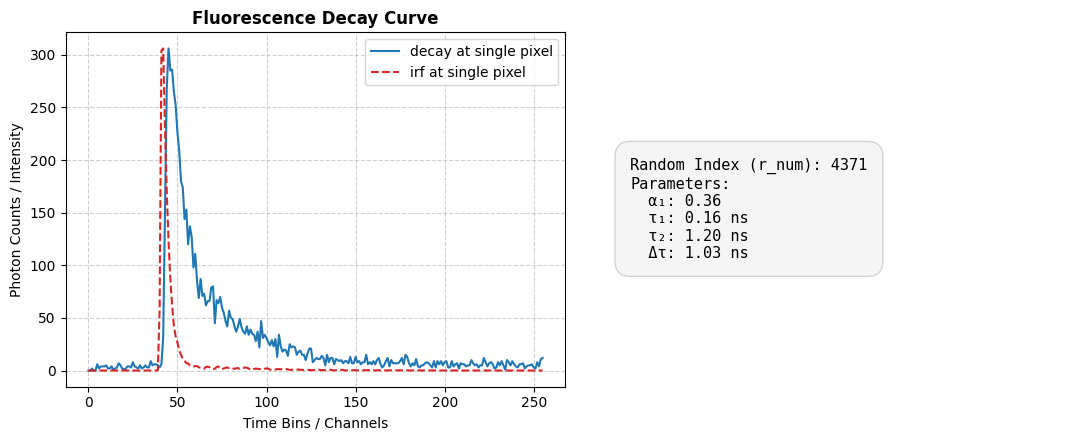

In [48]:
r_num = np.random.randint(NUM_SAMPLES)
tau_dif = sim_data["tau2"] - sim_data["tau1"]

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))

axs[0].plot(sim_data["decay"][r_num], color="tab:blue", linewidth=1.5, label="decay at single pixel")
axs[0].plot(
    Normalization(sim_data["irf"][r_num]).norm_scale(sim_data["decay"][r_num]),
    color="tab:red",
    linewidth=1.5,
    linestyle="--",
    label="irf at single pixel",
)
axs[0].set_title("Fluorescence Decay Curve", fontsize=12, fontweight="bold")
axs[0].set_xlabel("Time Bins / Channels", fontsize=10)
axs[0].set_ylabel("Photon Counts / Intensity", fontsize=10)
axs[0].grid(True, linestyle="--", alpha=0.6)
axs[0].legend(loc="upper right")

axs[1].axis("off")
text_content = (
    f"Random Index (r_num): {r_num}\n"
    f"Parameters:\n"
    f"  α₁: {sim_data['alpha1'][r_num]:.2f}\n"
    f"  τ₁: {sim_data['tau1'][r_num]:.2f} ns\n"
    f"  τ₂: {sim_data['tau2'][r_num]:.2f} ns\n"
    f"  Δτ: {tau_dif[r_num]:.2f} ns"
)

axs[1].text(
    0.1,
    0.5,
    text_content,
    fontsize=11,
    family="monospace",
    va="center",
    ha="left",
    bbox=dict(boxstyle="round,pad=1", facecolor="whitesmoke", edgecolor="lightgray"),
)

plt.tight_layout()

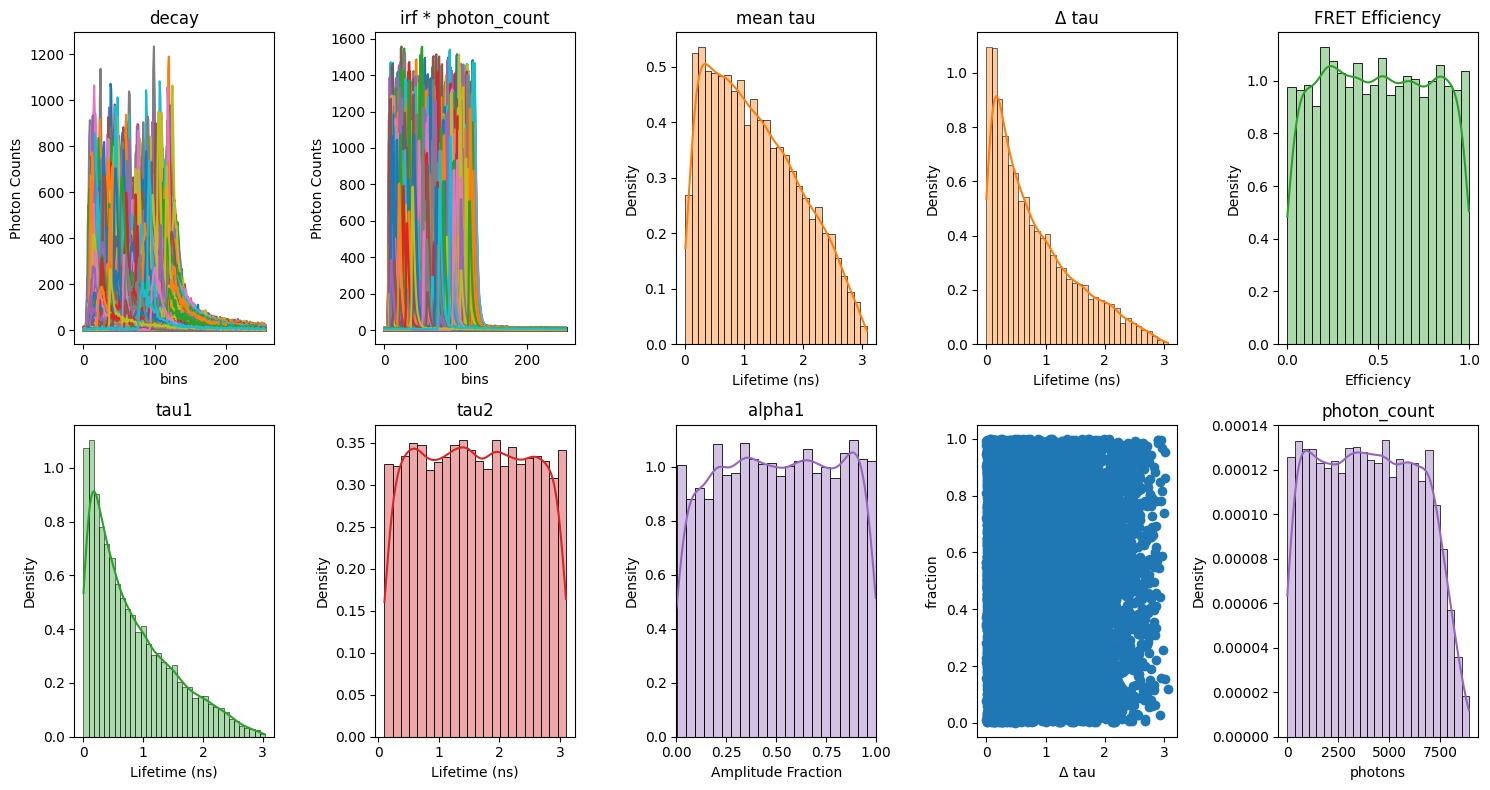

In [50]:
fig, axes = plt.subplots(2, 5, figsize=(15, 8))


axes[0, 0].plot((sim_data["decay"]).T)
axes[0, 0].set_title("decay")
axes[0, 0].set_xlabel("bins")
axes[0, 0].set_ylabel("Photon Counts")

axes[0, 1].plot((sim_data["irf"]).T * (sim_data["photon_count"]).T)
axes[0, 1].set_title("irf * photon_count")
axes[0, 1].set_xlabel("bins")
axes[0, 1].set_ylabel("Photon Counts")


sns.histplot(
    data=sim_data["tau"].flatten(),
    ax=axes[0, 2],
    kde=True,
    stat="density",
    color="tab:orange",
    alpha=0.4,
)
axes[0, 2].set_title("mean tau")
axes[0, 2].set_xlabel("Lifetime (ns)")

sns.histplot(
    data=tau_dif.flatten(),
    ax=axes[0, 3],
    kde=True,
    stat="density",
    color="tab:orange",
    alpha=0.4,
)
axes[0, 3].set_title("Δ tau")
axes[0, 3].set_xlabel("Lifetime (ns)")


sns.histplot(
    data=sim_data["Efficiency"].flatten(),
    ax=axes[0, 4],
    kde=True,
    stat="density",
    color="tab:green",
    alpha=0.4,
)
axes[0, 4].set_title("FRET Efficiency")
axes[0, 4].set_xlabel("Efficiency")

sns.histplot(
    data=sim_data["tau1"].flatten(),
    ax=axes[1, 0],
    kde=True,
    stat="density",
    color="tab:green",
    alpha=0.4,
)
axes[1, 0].set_title("tau1")
axes[1, 0].set_xlabel("Lifetime (ns)")


sns.histplot(
    data=sim_data["tau2"].flatten(),
    ax=axes[1, 1],
    kde=True,
    stat="density",
    color="tab:red",
    alpha=0.4,
)
axes[1, 1].set_title("tau2")
axes[1, 1].set_xlabel("Lifetime (ns)")

sns.histplot(
    data=sim_data["alpha1"].flatten(),
    ax=axes[1, 2],
    kde=True,
    stat="density",
    color="tab:purple",
    alpha=0.4,
)
axes[1, 2].set_title("alpha1")
axes[1, 2].set_xlabel("Amplitude Fraction")
axes[1, 2].set_xlim(0.0, 1.0)


sns.histplot(
    data=sim_data["photon_count"].flatten(),
    ax=axes[1, 4],
    kde=True,
    stat="density",
    color="tab:purple",
    alpha=0.4,
)
axes[1, 4].set_title("photon_count")
axes[1, 4].set_xlabel("photons")
# axes[1, 4].set_xlim(0.0, 1.0)


axes[1, 3].scatter(tau_dif, sim_data["alpha1"])
axes[1, 3].set_xlabel("Δ tau")
axes[1, 3].set_ylabel("fraction")

plt.tight_layout()
plt.show()